# Malicious URL Dataset (malicious_phish.csv)

## Dataset Overview

The **malicious_phish.csv** dataset is a large-scale collection of URLs designed for malicious URL detection research and machine learning applications. It contains both legitimate (benign) and multiple categories of malicious URLs, making it suitable for developing binary and multi-class URL classification models.

The dataset was created by combining several publicly available cybersecurity datasets, resulting in a diverse collection of URLs from different sources. Each record consists of a URL and its corresponding label, allowing machine learning and deep learning models to learn the characteristics of malicious web addresses.

---

## Dataset Statistics

| Class | Number of URLs |
|--------|---------------:|
| Benign | 428,103 |
| Defacement | 96,457 |
| Phishing | 94,111 |
| Malware | 32,520 |
| **Total** | **651,191** |

---

## Dataset Sources

The dataset was curated by combining URLs from multiple publicly available sources, including:

- ISCX URL 2016
- Malware Domain Blacklist
- PhishTank
- PhishStorm
- Additional benign URL repositories

The URLs from these sources were merged, cleaned, and labeled to create a unified dataset suitable for machine learning research.

---

# Project Objective

This dataset serves as the primary training dataset for the **Deep Learning Model (Model 2)** in the NullThreat project.

Unlike our first model, which relies on handcrafted lexical features, this model learns directly from the raw URL text. By analyzing the sequence of characters within a URL, the model aims to automatically identify malicious patterns without manual feature engineering.

The trained model will later be combined with the XGBoost classifier using an ensemble learning approach to improve the overall detection performance.

---

## Project Goals

Using this dataset, we aim to:

- Develop a Character-Level BiLSTM model for malicious URL detection.
- Learn URL patterns directly from raw text.
- Distinguish between benign and malicious URLs with high accuracy.
- Build a model capable of generalizing to previously unseen URLs.
- Integrate the trained model into the NullThreat browser extension for real-time URL classification.
- Support future continuous retraining by incorporating newly collected threat intelligence into the dataset.

---

## Workflow

```
Raw URL Dataset
        │
        ▼
Data Cleaning & Validation
        │
        ▼
Label Encoding
        │
        ▼
Character Tokenization
        │
        ▼
Sequence Padding
        │
        ▼
Character-Level BiLSTM
        │
        ▼
Model Evaluation
        │
        ▼
Ensemble with XGBoost
        │
        ▼
Real-Time Malicious URL Detection
```

In [1]:
import os 
import sys 

# Add the project root to Python's search path
project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd 
from src.utils import dataset_summary
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder
import joblib 
import string
import unicodedata
import re
import html.entities
from src.tokenizer import (build_vocabulary, save_vocabulary, load_vocabulary, encode_urls, pad_sequences)
import numpy as np 
import torch 
from src.dataset import URLDataset
from torch.utils.data import DataLoader
from model import URLClassifier

In [3]:
# Loading dataset 

with open('../dataset/malicious_phish.csv', 'r') as f:
    df = pd.read_csv(f)


In [4]:
# dataset summary 
dataset_summary(df)

Shape: (651191, 2)
Columns: ['url', 'type']

Data Types:
url     str
type    str
dtype: object

Missing Values:
url     0
type    0
dtype: int64

Duplicate Rows: 10066

Class Distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64


# Step 2: Exploratory Data Analysis (EDA)

The purpose of Exploratory Data Analysis (EDA) is to understand the characteristics of the dataset before performing any preprocessing.

In this step, we examine the distribution of URL classes, inspect URL lengths, identify duplicate records, and look for anomalies that may affect model performance.

A thorough understanding of the dataset helps us design an appropriate preprocessing pipeline and avoid introducing unnecessary bias during model training.

In [5]:
# FInding proportion of each class in dataset 
df['type'].value_counts(normalize=True).mul(100).round(2)

type
benign        65.74
defacement    14.81
phishing      14.45
malware        4.99
Name: proportion, dtype: float64

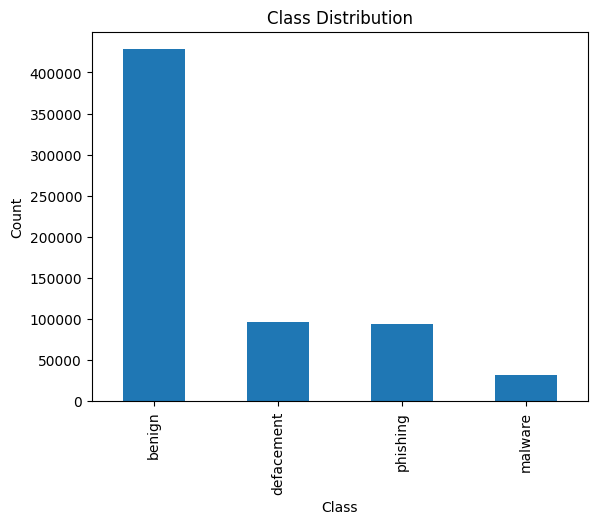

In [6]:
# Visualize class Distribution 

df['type'].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [7]:
df["url_length"] = df["url"].str.len()

In [8]:
df["url_length"].describe()

count    651191.000000
mean         60.156831
std          44.753902
min           1.000000
25%          32.000000
50%          47.000000
75%          77.000000
max        2175.000000
Name: url_length, dtype: float64

In [9]:
df.head()

,url,type,url_length
0,br-icloud.com.br,phishing,16
1,mp3raid.com/music/krizz_kaliko.html,benign,35
2,bopsecrets.org/rexroth/cr/1.htm,benign,31
3,http://www.garage-pirenne.be/index.php?option=...,defacement,88
4,http://adventure-nicaragua.net/index.php?optio...,defacement,235


In [10]:
df['url_length'].describe()

count    651191.000000
mean         60.156831
std          44.753902
min           1.000000
25%          32.000000
50%          47.000000
75%          77.000000
max        2175.000000
Name: url_length, dtype: float64

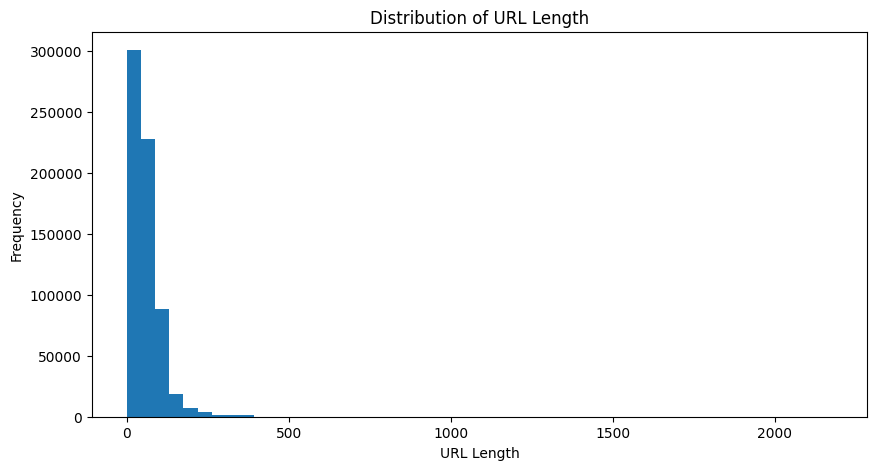

In [11]:
# Distribution of URL Lengths

plt.figure(figsize=(10,5))
plt.hist(df['url_length'], bins=50)
plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.ylabel("Frequency")

plt.show()

In [12]:
# Longest URLs
df.nlargest(10, "url_length")[['url', 'url_length', 'type']]

,url,url_length,type
579857,peekaboopoles.co.uk/holding/payza.com/accounts...,2175,benign
457891,https://asana.com/guide/videos/%22//fast.wisti...,2081,benign
522782,https://nkfmwefiofjwefiwofjweiofwmejfowejfowfw...,1779,phishing
337711,https://lastpass.com/signup2.php?ac=1&from_uri...,1696,benign
527949,https://dev.seatassignmate.net/latam/payment_o...,1641,phishing
528379,http://193.35.48.23/0787631061/?u=y2ykaew&amp;...,1535,phishing
44224,https://lastpass.com/signup2.php?ac=1&from_uri...,1517,benign
524316,http://licogi18.com.vn/login.microsoftonline.c...,1386,phishing
531422,http://licogi18.com.vn/login.microsoftonline.c...,1386,phishing
199338,https://lastpass.com/signup2.php?ac=1&from_uri...,1348,benign


In [13]:
# Shortest URLs
df.nsmallest(10, 'url_length')[['url','url_length','type']]

,url,url_length,type
573437,,1,phishing
573468,ºE,2,phishing
573471,WY,2,phishing
573446,½4+,4,phishing
374391,1b.yt,5,phishing
573423,¾5092,5,phishing
573449,=Â-,5,phishing
573485,)-,5,phishing
39326,bel.az,6,phishing
94758,nab.vu,6,phishing


In [14]:
# Duplicate URLs
df['url'].duplicated().sum()

np.int64(10072)

In [15]:
duplicate_labels = (
    df.groupby("url")["type"].nunique()
)

duplicate_labels[duplicate_labels > 1]

url
ebookstore.sony.com/reader/                    2
en.wikipedia.org/wiki/Desktop_publishing       2
en.wikipedia.org/wiki/E-book                   2
groups.yahoo.com/group/Band-in-a-Box/          2
memory.loc.gov/ammem/ccmphtml/colahome.html    2
routesinternational.com/air.htm                2
Name: type, dtype: int64

The above is the issue that same url have 2 labels, this issue is solved below

In [16]:
characters = sorted(set("".join(df["url"])))

print(characters)
print(len(characters))

['\x01', '\x02', '\x03', '\x04', '\x05', '\x06', '\x07', '\x08', '\t', '\n', '\x0b', '\x0c', '\x0e', '\x0f', '\x10', '\x11', '\x12', '\x13', '\x14', '\x15', '\x16', '\x17', '\x18', '\x19', '\x1a', '\x1b', '\x1c', '\x1d', '\x1e', '\x1f', ' ', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '<', '=', '>', '?', '@', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', '\\', ']', '^', '_', '`', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', '{', '|', '}', '~', '\x7f', '\x80', '\x81', '\x82', '\x83', '\x84', '\x85', '\x86', '\x87', '\x88', '\x89', '\x8a', '\x8b', '\x8c', '\x8d', '\x8e', '\x8f', '\x90', '\x91', '\x92', '\x93', '\x94', '\x95', '\x96', '\x97', '\x98', '\x99', '\x9a', '\x9b', '\x9c', '\x9d', '\x9e', '\x9f', '\xa0', '¡', '¢', '£', 

## Data Cleaning 

In [17]:
df = df.drop_duplicates(subset="url")

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

url           0
type          0
url_length    0
dtype: int64

In [20]:
df = df.dropna(subset=["url", "type"])

In [21]:
df = df[df["url"].str.strip() != ""]

In [22]:
df.shape

(641119, 3)

In [23]:
# Checking the duplicated labels url

conflicting_urls = duplicate_labels[duplicate_labels > 1].index

df[df["url"].isin(conflicting_urls)].sort_values("url")

,url,type,url_length
328665,ebookstore.sony.com/reader/,benign,27
259609,en.wikipedia.org/wiki/Desktop_publishing,benign,40
213051,en.wikipedia.org/wiki/E-book,benign,28
275788,groups.yahoo.com/group/Band-in-a-Box/,benign,37
181226,memory.loc.gov/ammem/ccmphtml/colahome.html,benign,43
208439,routesinternational.com/air.htm,benign,31


In [24]:
# Saving conflicating record before removing for documentations 
conflicting_records = df[df["url"].isin(conflicting_urls)]
conflicting_records

,url,type,url_length
181226,memory.loc.gov/ammem/ccmphtml/colahome.html,benign,43
208439,routesinternational.com/air.htm,benign,31
213051,en.wikipedia.org/wiki/E-book,benign,28
259609,en.wikipedia.org/wiki/Desktop_publishing,benign,40
275788,groups.yahoo.com/group/Band-in-a-Box/,benign,37
328665,ebookstore.sony.com/reader/,benign,27


In [25]:
# Removing the conflicting urls
df = df[~df["url"].isin(conflicting_urls)]

In [26]:
# Verifying...

duplicate_labels = df.groupby("url")["type"].nunique()

duplicate_labels[duplicate_labels > 1]

Series([], Name: type, dtype: int64)

In [27]:
df['type'].unique()

<StringArray>
['phishing', 'benign', 'defacement', 'malware']
Length: 4, dtype: str

In [28]:
# URL Normalization 

df["url"] = df["url"].str.strip()

In [29]:
df["url"] = df["url"].str.lower()

### Train test split dataset 

In [30]:
# First split: Training 70% and Temporary 30%

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['type'],
    random_state=42,
    shuffle=True
)


# Second split: Validation 15% and Test 15%

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['type'],
    random_state=42,
    shuffle=True
)

In [31]:
# Verifying 

print(f"Training Set   : {len(train_df):,}")
print(f"Validation Set : {len(val_df):,}")
print(f"Test Set       : {len(test_df):,}")

Training Set   : 448,779
Validation Set : 96,167
Test Set       : 96,167


In [32]:
print("Training Distribution")
print(train_df['type'].value_counts(normalize=True) * 100)
print("\nValidation Distribution")
print(val_df['type'].value_counts(normalize=True) * 100)
print("\nTest Distribution")
print(train_df['type'].value_counts(normalize=True) * 100)

Training Distribution
type
benign        66.770504
defacement    14.866115
phishing      14.675375
malware        3.688007
Name: proportion, dtype: float64

Validation Distribution
type
benign        66.770306
defacement    14.865806
phishing      14.675512
malware        3.688375
Name: proportion, dtype: float64

Test Distribution
type
benign        66.770504
defacement    14.866115
phishing      14.675375
malware        3.688007
Name: proportion, dtype: float64


In [33]:
label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["type"])
val_df["label"] = label_encoder.transform(val_df["type"])
test_df["label"] = label_encoder.transform(test_df["type"])

In [34]:
# Checkingn the mapping 

for index, label in enumerate(label_encoder.classes_):
    print(f"{label} -> {index}")

benign -> 0
defacement -> 1
malware -> 2
phishing -> 3


In [35]:
# verifying the encoded labels 

train_df[["type", "label"]].head(10)

,type,label
58051,benign,0
185376,benign,0
39180,benign,0
293000,benign,0
366974,benign,0
215529,benign,0
343949,defacement,1
595113,benign,0
553545,malware,2
574675,benign,0


In [36]:
# Save the label encoder 
joblib.dump(label_encoder, "artifacts/label_encoder.pkl")

['artifacts/label_encoder.pkl']

In [37]:
# Collect all the unique characters 

unique_characters = sorted(set("".join(train_df["url"])))

print(f"Vocabulary size (without any tokens): {len(unique_characters)}")

Vocabulary size (without any tokens): 269


In [38]:
# Creating the vocabulary 
vocab = {
    '<PAD>': 0,
    '<UNK>': 1
}

for idx, char in enumerate(unique_characters, start=2):
    vocab[char] = idx

In [39]:
# Verifying...

list(vocab.items())[:20]

[('<PAD>', 0),
 ('<UNK>', 1),
 ('\x01', 2),
 ('\x02', 3),
 ('\x03', 4),
 ('\x04', 5),
 ('\x05', 6),
 ('\x06', 7),
 ('\x07', 8),
 ('\x08', 9),
 ('\t', 10),
 ('\n', 11),
 ('\x0b', 12),
 ('\x0c', 13),
 ('\x0e', 14),
 ('\x0f', 15),
 ('\x10', 16),
 ('\x11', 17),
 ('\x12', 18),
 ('\x13', 19)]

In [40]:
non_printable = sorted(
    ch for ch in unique_characters
    if ch not in string.printable
)

print(non_printable)

['\x01', '\x02', '\x03', '\x04', '\x05', '\x06', '\x07', '\x08', '\x0e', '\x0f', '\x10', '\x11', '\x12', '\x13', '\x14', '\x15', '\x16', '\x17', '\x18', '\x19', '\x1a', '\x1b', '\x1c', '\x1d', '\x1e', '\x1f', '\x7f', '\x80', '\x81', '\x82', '\x83', '\x84', '\x85', '\x86', '\x87', '\x88', '\x89', '\x8a', '\x8b', '\x8c', '\x8d', '\x8e', '\x8f', '\x90', '\x91', '\x92', '\x93', '\x94', '\x95', '\x96', '\x97', '\x98', '\x99', '\x9a', '\x9b', '\x9c', '\x9d', '\x9e', '\x9f', '\xa0', '¡', '¢', '£', '¤', '¥', '¦', '§', '¨', '©', 'ª', '«', '¬', '\xad', '®', '¯', '°', '±', '²', '³', '´', 'µ', '¶', '·', '¸', '¹', 'º', '»', '¼', '½', '¾', '¿', '×', 'ß', 'à', 'á', 'â', 'ã', 'ä', 'å', 'æ', 'ç', 'è', 'é', 'ê', 'ë', 'ì', 'í', 'î', 'ï', 'ð', 'ñ', 'ò', 'ó', 'ô', 'õ', 'ö', '÷', 'ø', 'ù', 'ú', 'û', 'ü', 'ý', 'þ', 'ÿ', 'š', 'ž', 'ƒ', 'ˆ', 'ก', 'ข', 'ฃ', 'ค', 'ฅ', 'ง', 'จ', 'ฉ', 'ช', 'ซ', 'ฌ', 'ญ', 'ฎ', 'ฏ', 'ฐ', 'ฑ', 'ฒ', 'ณ', 'ด', 'ต', 'ถ', 'ท', 'ธ', 'น', 'บ', 'ป', 'ผ', 'ฝ', 'พ', 'ฟ', 'ย', 'ร', 'ฤ', 'ล', '

In [41]:
print(len(non_printable))

196


In [42]:
print(repr(non_printable[:20]))

['\x01', '\x02', '\x03', '\x04', '\x05', '\x06', '\x07', '\x08', '\x0e', '\x0f', '\x10', '\x11', '\x12', '\x13', '\x14', '\x15', '\x16', '\x17', '\x18', '\x19']


In [43]:
# Checking the characters are just controled characters or just unicode characters

for ch in non_printable[:20]:
    print(repr(ch), unicodedata.name(ch, "UNKNOWN"))

'\x01' UNKNOWN
'\x02' UNKNOWN
'\x03' UNKNOWN
'\x04' UNKNOWN
'\x05' UNKNOWN
'\x06' UNKNOWN
'\x07' UNKNOWN
'\x08' UNKNOWN
'\x0e' UNKNOWN
'\x0f' UNKNOWN
'\x10' UNKNOWN
'\x11' UNKNOWN
'\x12' UNKNOWN
'\x13' UNKNOWN
'\x14' UNKNOWN
'\x15' UNKNOWN
'\x16' UNKNOWN
'\x17' UNKNOWN
'\x18' UNKNOWN
'\x19' UNKNOWN


In [44]:
# Finding the corrupted rows 

control_pattern = r"[\x00-\x1F\x7F]"

problem_rows = train_df[
    train_df["url"].astype(str).str.contains(control_pattern, regex=True, na=False)
]

print(problem_rows.shape)

problem_rows[["url", "type"]].head(20)

(55, 4)


,url,type
573435,"_wªçm`""éñ¦m9 mpúôoà ¿ã±µäláéýrñ{öê...",phishing
573508,þ~³\(ÿç½jú$xm £üëã5{¾küãcê_qê©b çèc2...,phishing
573436,esxcc.com/js/index.htm?us.battle.net/logmn+en¯...,phishing
573465,oíñoweuêúãß=nëß[j{2%.tñø­½½qx½nºpmx$aì&...,phishing
573490,ók¦¾þ)j&´^áyêïfg>|½}¸! î©q¶ú5y½êtjà&ëû ...,phishing
573507,«düéºþ +zidn ö-lh9l©hdkäúhßæ%yqã±¹d,phishing
573426,@ òê \ t¹ë¨öí ,phishing
573446,½4+,phishing
573463,"`) ""v§;",phishing
573504,uéò×õa,phishing


In [45]:
# Function to remove corrputed rows 

def remove_control_character_rows(df):

    pattern = r"[\x00-\x1F\x7F]"


    bad_rows = df[df["url"].astype(str).str.contains(pattern, regex=True, na=False)]

    print(f"Removing {len(bad_rows)} corrupted URLs")


    return (
        df.drop(bad_rows.index).reset_index(drop=True)
    )

In [46]:
train_df = remove_control_character_rows(train_df)
val_df = remove_control_character_rows(val_df)
test_df = remove_control_character_rows(test_df)

Removing 55 corrupted URLs
Removing 20 corrupted URLs
Removing 13 corrupted URLs


In [47]:
# Remove leading and trailing whitespace
train_df["url"] = train_df["url"].str.strip()
val_df["url"] = val_df["url"].str.strip()
test_df["url"] = test_df["url"].str.strip()

In [48]:
# Function for Removing internal whitespace inside url with 20% and converting html valid entities --> back to normal
def normalize_urls(df):
    df = df.copy()

    df["url"] = (
        df["url"]
        .astype(str)
        .str.strip()
        .str.replace(" ", "%20", regex=False)
        .apply(html.unescape)  # html entities converting 
    )

    return df

In [49]:
train_df = normalize_urls(train_df)
val_df = normalize_urls(val_df)
test_df = normalize_urls(test_df)

In [50]:
# Building the vocabulary 

char2idx, idx2char = build_vocabulary(train_df["url"])


In [51]:
# Recreating the vocabulary 

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for idx, char in enumerate(unique_characters, start=2):
    vocab[char] = idx

In [52]:
# Verifying the space in the URLs
space_rows = train_df[
    train_df["url"].str.contains(" ", regex=False, na=False)
]

print(f"URLs containing spaces: {len(space_rows)}")
space_rows[["url", "type"]].head(10)

URLs containing spaces: 0


,url,type


In [53]:
# checking rows 
url = train_df.loc[1712, "url"]

print(url)
print(repr(url))

http://nef.com.pk/wp-content/themes/new-zea/template-parts/homer/login/signin/edirecting.php?bmvmlmnvbs5way93cc1jb250zw50l3rozw1lcy9uzxctemvhl3rlbxbsyxrllxbhcnrzl2hvbwvyl2xvz2lul3npz25pbi9lzgl%20-->
'http://nef.com.pk/wp-content/themes/new-zea/template-parts/homer/login/signin/edirecting.php?bmvmlmnvbs5way93cc1jb250zw50l3rozw1lcy9uzxctemvhl3rlbxbsyxrllxbhcnrzl2hvbwvyl2xvz2lul3npz25pbi9lzgl%20-->'


In [54]:
indices = [1712, 1731, 3870, 8677, 15023]

for idx in indices:
    print(f"\nIndex: {idx}")
    print(repr(train_df.loc[idx, "url"]))



Index: 1712
'http://nef.com.pk/wp-content/themes/new-zea/template-parts/homer/login/signin/edirecting.php?bmvmlmnvbs5way93cc1jb250zw50l3rozw1lcy9uzxctemvhl3rlbxbsyxrllxbhcnrzl2hvbwvyl2xvz2lul3npz25pbi9lzgl%20-->'

Index: 1731
"'onin.com/fp/afis/afis.html#miscellaneous%20sites'"

Index: 3870
"'charmaineyoest.com/import/remax/secure%20login.html'"

Index: 8677
"'justhandcrafted.com/remax%20properties/'"

Index: 15023
"'anunaki.be/remax/secure%20login.html'"


In [55]:
# Checking html entities in the urls 

html_pattern = r"&[a-zA-Z]+;"

html_rows = train_df[
    train_df['url'].str.contains(html_pattern, regex=True, na=False)
]

print(f"Rows contaning HTML entities: {len(html_rows)}")

html_rows[["url", "type"]].head(10)

Rows contaning HTML entities: 901


,url,type
16,www.jinyangrb.com/js/?secure.runescape.com/m=3...,benign
325,us.battle.net.login.en.eb-login.com/login/en/l...,benign
676,us.battle.net.ok.qw-rs.com/login/en/login.html...,benign
1950,zcets.com/js/?us.battle.net/login/en/?ref=us.b...,benign
1976,www.hsqxx.com/js/?amp;us.battle.net/login/en/?...,benign
2017,www.nbgtwz.com/images/?secure.runescape.com/m=...,benign
2364,stary.zielonyogrodek.pl/pp/webscr.php?cmd=_log...,benign
2393,www.lnhcxh.com.cn/images/?secure.runescape.com...,benign
2534,'www.wzae.com.cn/js/?us.battle.net/login/en/re...,benign
3590,www.mariachisadomicilio.cl/images/ben/8a68aece...,benign


In [56]:
# Saving Vocabulary 

ARTIFACTS_DIR = "artifacts"
save_vocabulary(char2idx, idx2char, ARTIFACTS_DIR)

In [57]:
# Encoding urls
X_train_encoded = encode_urls(train_df["url"], char2idx)
X_val_encoded = encode_urls(val_df["url"], char2idx)
X_test_encoded = encode_urls(test_df["url"], char2idx)

In [58]:
# Verifying...
print(train_df["url"].iloc[0])

print(X_train_encoded[0])

cbn.com/spirituallife/prayerandcounseling/intercession/praying_john_hyde.aspx
[42, 41, 53, 15, 42, 54, 52, 16, 58, 55, 48, 57, 48, 59, 60, 40, 51, 51, 48, 45, 44, 16, 55, 57, 40, 64, 44, 57, 40, 53, 43, 42, 54, 60, 53, 58, 44, 51, 48, 53, 46, 16, 48, 53, 59, 44, 57, 42, 44, 58, 58, 48, 54, 53, 16, 55, 57, 40, 64, 48, 53, 46, 38, 49, 54, 47, 53, 38, 47, 64, 43, 44, 15, 40, 58, 55, 63]


In [59]:
# URL Length analysis for padding 

train_df["url"].str.len().describe(percentiles=[0.90,0.95,0.99])

count    448724.000000
mean         59.678647
std          44.499204
min           2.000000
90%         107.000000
95%         134.000000
99%         234.000000
max        2175.000000
Name: url, dtype: float64

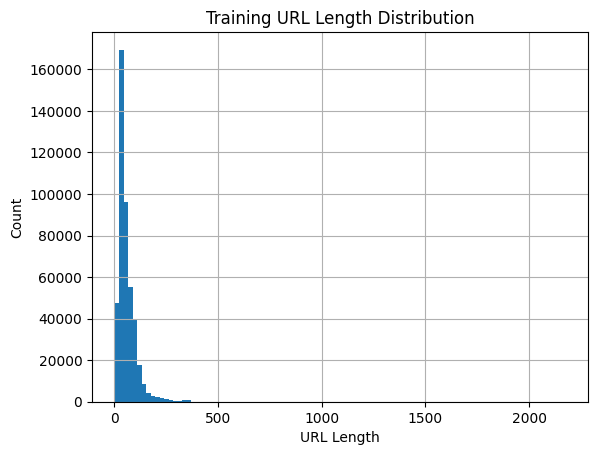

In [60]:
# Analysis with plot 

train_df["url"].str.len().hist(bins=100)

plt.xlabel("URL Length")
plt.ylabel("Count")
plt.title("Training URL Length Distribution")

plt.show()

In [61]:
#Padding train, validation, test 

MAX_LENGTH = 256

X_train = pad_sequences(X_train_encoded, max_length=MAX_LENGTH)
X_val = pad_sequences(X_val_encoded, max_length=MAX_LENGTH)
X_test = pad_sequences(X_test_encoded, max_length=MAX_LENGTH)


In [62]:
# Extracting labels from dataframes 

y_train = train_df["label"].to_numpy()

y_val = val_df["label"].to_numpy()

y_test = test_df["label"].to_numpy()

In [63]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(448724, 256)
(96147, 256)
(96154, 256)
(448724,)
(96147,)
(96154,)


In [64]:
# Saving the artifacts 

np.save("artifacts/X_train.npy", X_train)
np.save("artifacts/X_val.npy", X_val)
np.save("artifacts/X_test.npy", X_test)

np.save("artifacts/y_train.npy", y_train)
np.save("artifacts/y_val.npy", y_val)
np.save("artifacts/y_test.npy", y_test)

In [65]:
# Verifying artifacts 
print(os.listdir("artifacts"))

['char2idx.json', 'idx2char', 'label_encoder.pkl', 'X_test.npy', 'X_train.npy', 'X_val.npy', 'y_test.npy', 'y_train.npy', 'y_val.npy']


In [66]:
#Final verification of shape

loaded_X_train = np.load("artifacts/X_train.npy")
print(loaded_X_train.shape)
print(X_train.shape)

(448724, 256)
(448724, 256)


In [67]:
# Testing dataset 

train_dataset = URLDataset(X_train, y_train)

print(len(train_dataset))

448724


In [68]:
sample_url, sample_label = train_dataset[0]


In [69]:
print("URL Tensor:")
print(sample_url)

print("\nURL Tensor Type:")
print(type(sample_url))

print("\nURL Tensor Shape:")
print(sample_url.shape)

print("\nURL Tensor Dtype:")
print(sample_url.dtype)

print("\nLabel:")
print(sample_label)

print("\nLabel Type:")
print(type(sample_label))

print("\nLabel Dtype:")
print(sample_label.dtype)

URL Tensor:


tensor([42, 41, 53, 15, 42, 54, 52, 16, 58, 55, 48, 57, 48, 59, 60, 40, 51, 51,
        48, 45, 44, 16, 55, 57, 40, 64, 44, 57, 40, 53, 43, 42, 54, 60, 53, 58,
        44, 51, 48, 53, 46, 16, 48, 53, 59, 44, 57, 42, 44, 58, 58, 48, 54, 53,
        16, 55, 57, 40, 64, 48, 53, 46, 38, 49, 54, 47, 53, 38, 47, 64, 43, 44,
        15, 40, 58, 55, 63,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0, 

In [70]:
# train_dataset  -->  Already created above 

val_dataset = URLDataset(X_val, y_val)

test_dataset = URLDataset(X_test, y_test)

In [71]:
# Creating the Dataloaders

BATCH_SIZE = 64 

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True 
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [72]:
# Each batch contain 64 URL an 64 labels, Verifying that...

urls, labels = next(iter(train_loader))

In [73]:
print(urls.shape)
print(labels.shape)

print(urls.dtype)
print(labels.dtype)

torch.Size([64, 256])
torch.Size([64])
torch.int64
torch.int64


In [74]:
# Testing our model 

model = URLClassifier(
    vocab_size=len(char2idx),
    embedding_dim=64,
    hidden_size=128, 
    num_layers=1,
    num_classes=4,
    dropout=0.3
)

In [75]:
dumm_input = torch.randint(
    low=1,
    high=len(char2idx),
    size=(32,256)
)

In [76]:
print(dumm_input.shape)

torch.Size([32, 256])


In [77]:
embedding_output = model.embedding(dumm_input)
print(embedding_output.shape)

torch.Size([32, 256, 64])


In [79]:
output, (hidden, cell) = model.lstm(embedding_output)
print(output.shape)

torch.Size([32, 256, 256])


In [80]:
print(hidden.shape)

torch.Size([2, 32, 128])


In [81]:
print(cell.shape)

torch.Size([2, 32, 128])


In [82]:
forward_hidden = hidden[-2]

In [83]:
print(forward_hidden.shape)

torch.Size([32, 128])


In [84]:
backward_hidden = hidden[-1]
print(backward_hidden.shape)

torch.Size([32, 128])


In [85]:
final_hidden = torch.cat(
    (forward_hidden, backward_hidden),
    dim=1
)

print(final_hidden.shape)

torch.Size([32, 256])


In [86]:
dropout_output = model.dropout(final_hidden)

print(dropout_output.shape)

torch.Size([32, 256])


In [87]:
logits = model.fc(dropout_output)

print(logits.shape)

torch.Size([32, 4])
